In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load database

In [22]:
df = pd.read_csv("diamonds.csv")
df = pd.DataFrame(df)
print(df)

       Unnamed: 0  carat        cut color clarity  depth  table  price     x  \
0               1   0.23      Ideal     E     SI2   61.5   55.0    326  3.95   
1               2   0.21    Premium     E     SI1   59.8   61.0    326  3.89   
2               3   0.23       Good     E     VS1   56.9   65.0    327  4.05   
3               4   0.29    Premium     I     VS2   62.4   58.0    334  4.20   
4               5   0.31       Good     J     SI2   63.3   58.0    335  4.34   
...           ...    ...        ...   ...     ...    ...    ...    ...   ...   
53935       53936   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75   
53936       53937   0.72       Good     D     SI1   63.1   55.0   2757  5.69   
53937       53938   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66   
53938       53939   0.86    Premium     H     SI2   61.0   58.0   2757  6.15   
53939       53940   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83   

          y     z  
0      3.98  2.43  

Data Clea

In [23]:
df.info()

df.isnull().sum()

df.duplicated().sum()
df.drop(columns=["Unnamed: 0"], inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 5.1 MB


In [4]:
X = df.drop("price", axis=1)

y = df["price"]

print(X.shape)
print(y.shape)

(53940, 9)
(53940,)


In [5]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(include=["object","string"]).columns

print(num_cols)

print(cat_cols)

Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='str')
Index(['cut', 'color', 'clarity'], dtype='str')


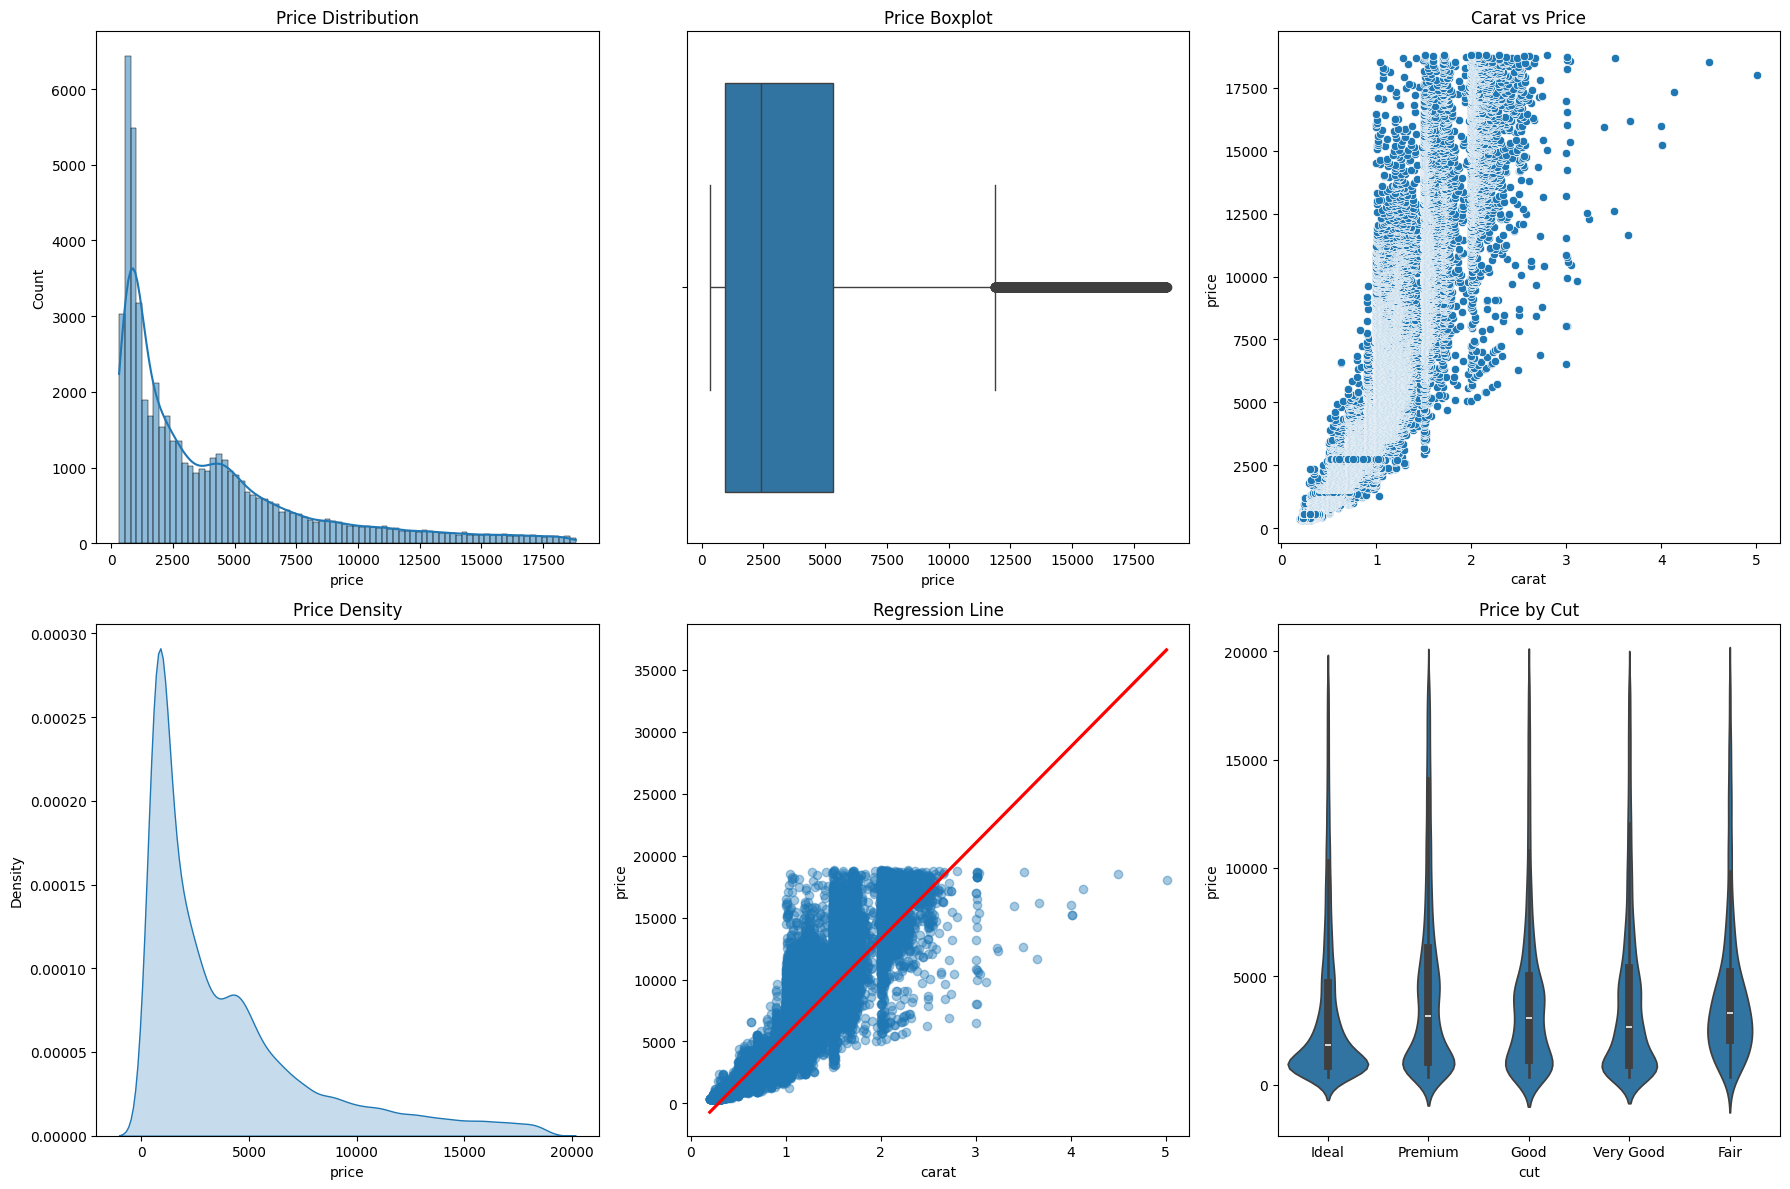

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histogram
sns.histplot(df["price"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Price Distribution")

# Boxplot
sns.boxplot(x=df["price"], ax=axes[0,1])
axes[0,1].set_title("Price Boxplot")

# Scatter Plot
sns.scatterplot(
    x="carat",
    y="price",
    data=df,
    ax=axes[0,2]
)
axes[0,2].set_title("Carat vs Price")

# KDE
sns.kdeplot(df["price"], fill=True, ax=axes[1,0])
axes[1,0].set_title("Price Density")

# Regression Plot
sns.regplot(
    x="carat",
    y="price",
    data=df,
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"},
    ax=axes[1,1]
)
axes[1,1].set_title("Regression Line")

# Violin Plot
sns.violinplot(
    x="cut",
    y="price",
    data=df,
    ax=axes[1,2]
)
axes[1,2].set_title("Price by Cut")

plt.tight_layout()
plt.show()

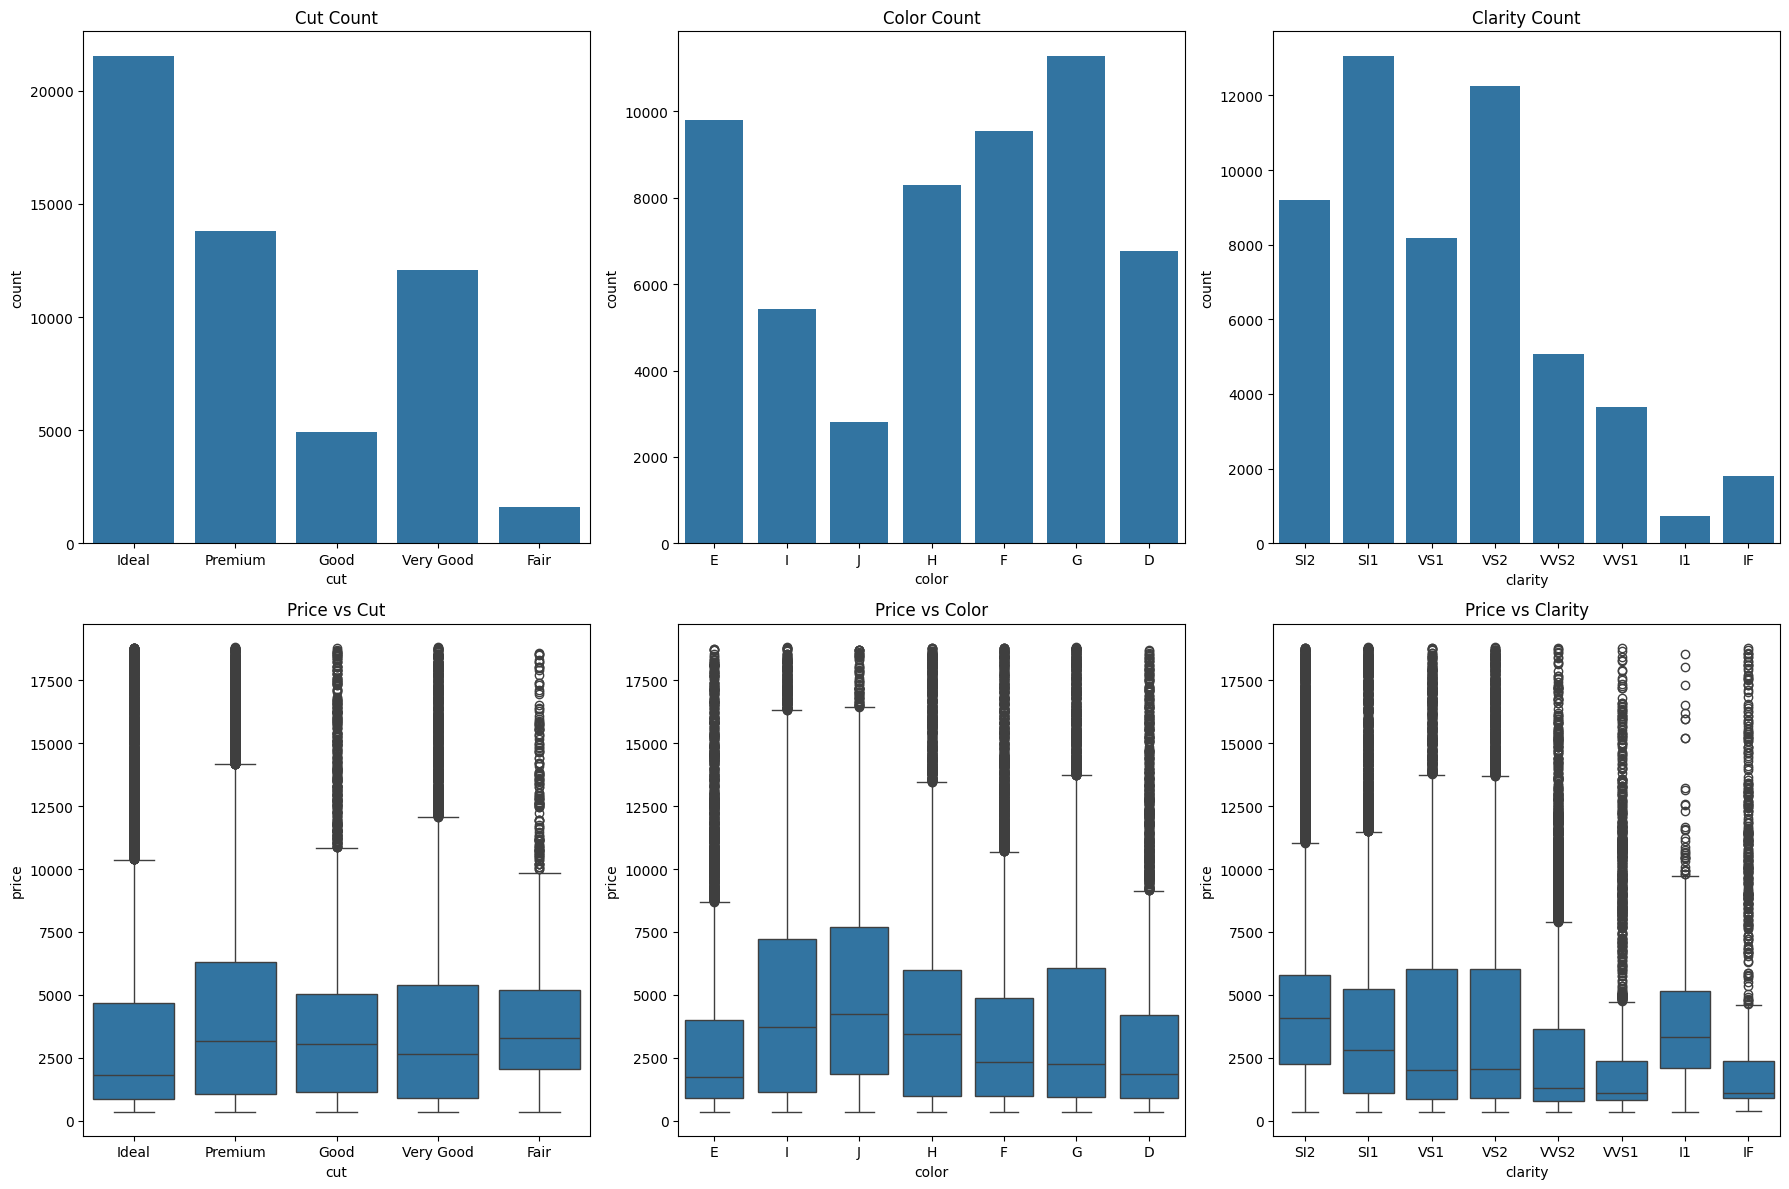

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.countplot(
    data=df,
    x="cut",
    ax=axes[0,0]
)
axes[0,0].set_title("Cut Count")

sns.countplot(
    data=df,
    x="color",
    ax=axes[0,1]
)
axes[0,1].set_title("Color Count")

sns.countplot(
    data=df,
    x="clarity",
    ax=axes[0,2]
)
axes[0,2].set_title("Clarity Count")

sns.boxplot(
    data=df,
    x="cut",
    y="price",
    ax=axes[1,0]
)
axes[1,0].set_title("Price vs Cut")

sns.boxplot(
    data=df,
    x="color",
    y="price",
    ax=axes[1,1]
)
axes[1,1].set_title("Price vs Color")

sns.boxplot(
    data=df,
    x="clarity",
    y="price",
    ax=axes[1,2]
)
axes[1,2].set_title("Price vs Clarity")

plt.tight_layout()
plt.show()

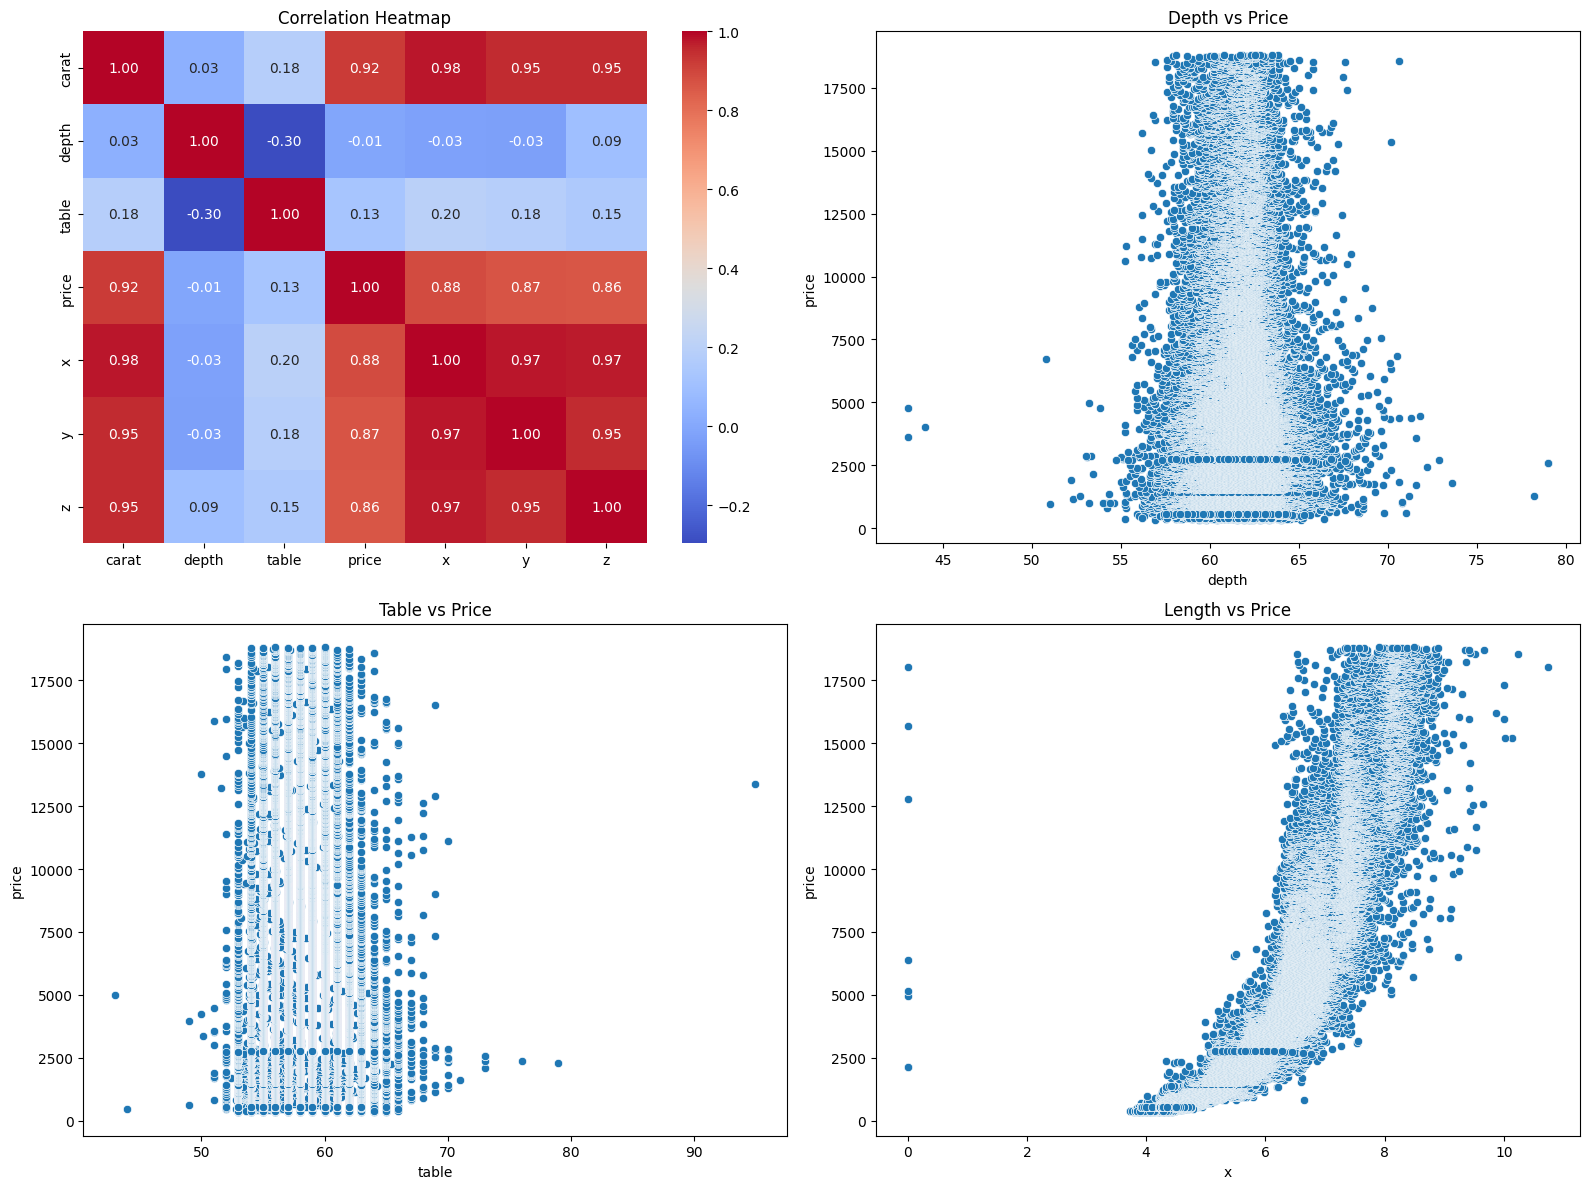

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0,0]
)
axes[0,0].set_title("Correlation Heatmap")

sns.scatterplot(
    data=df,
    x="depth",
    y="price",
    ax=axes[0,1]
)
axes[0,1].set_title("Depth vs Price")

sns.scatterplot(
    data=df,
    x="table",
    y="price",
    ax=axes[1,0]
)
axes[1,0].set_title("Table vs Price")

sns.scatterplot(
    data=df,
    x="x",
    y="price",
    ax=axes[1,1]
)
axes[1,1].set_title("Length vs Price")

plt.tight_layout()
plt.show()

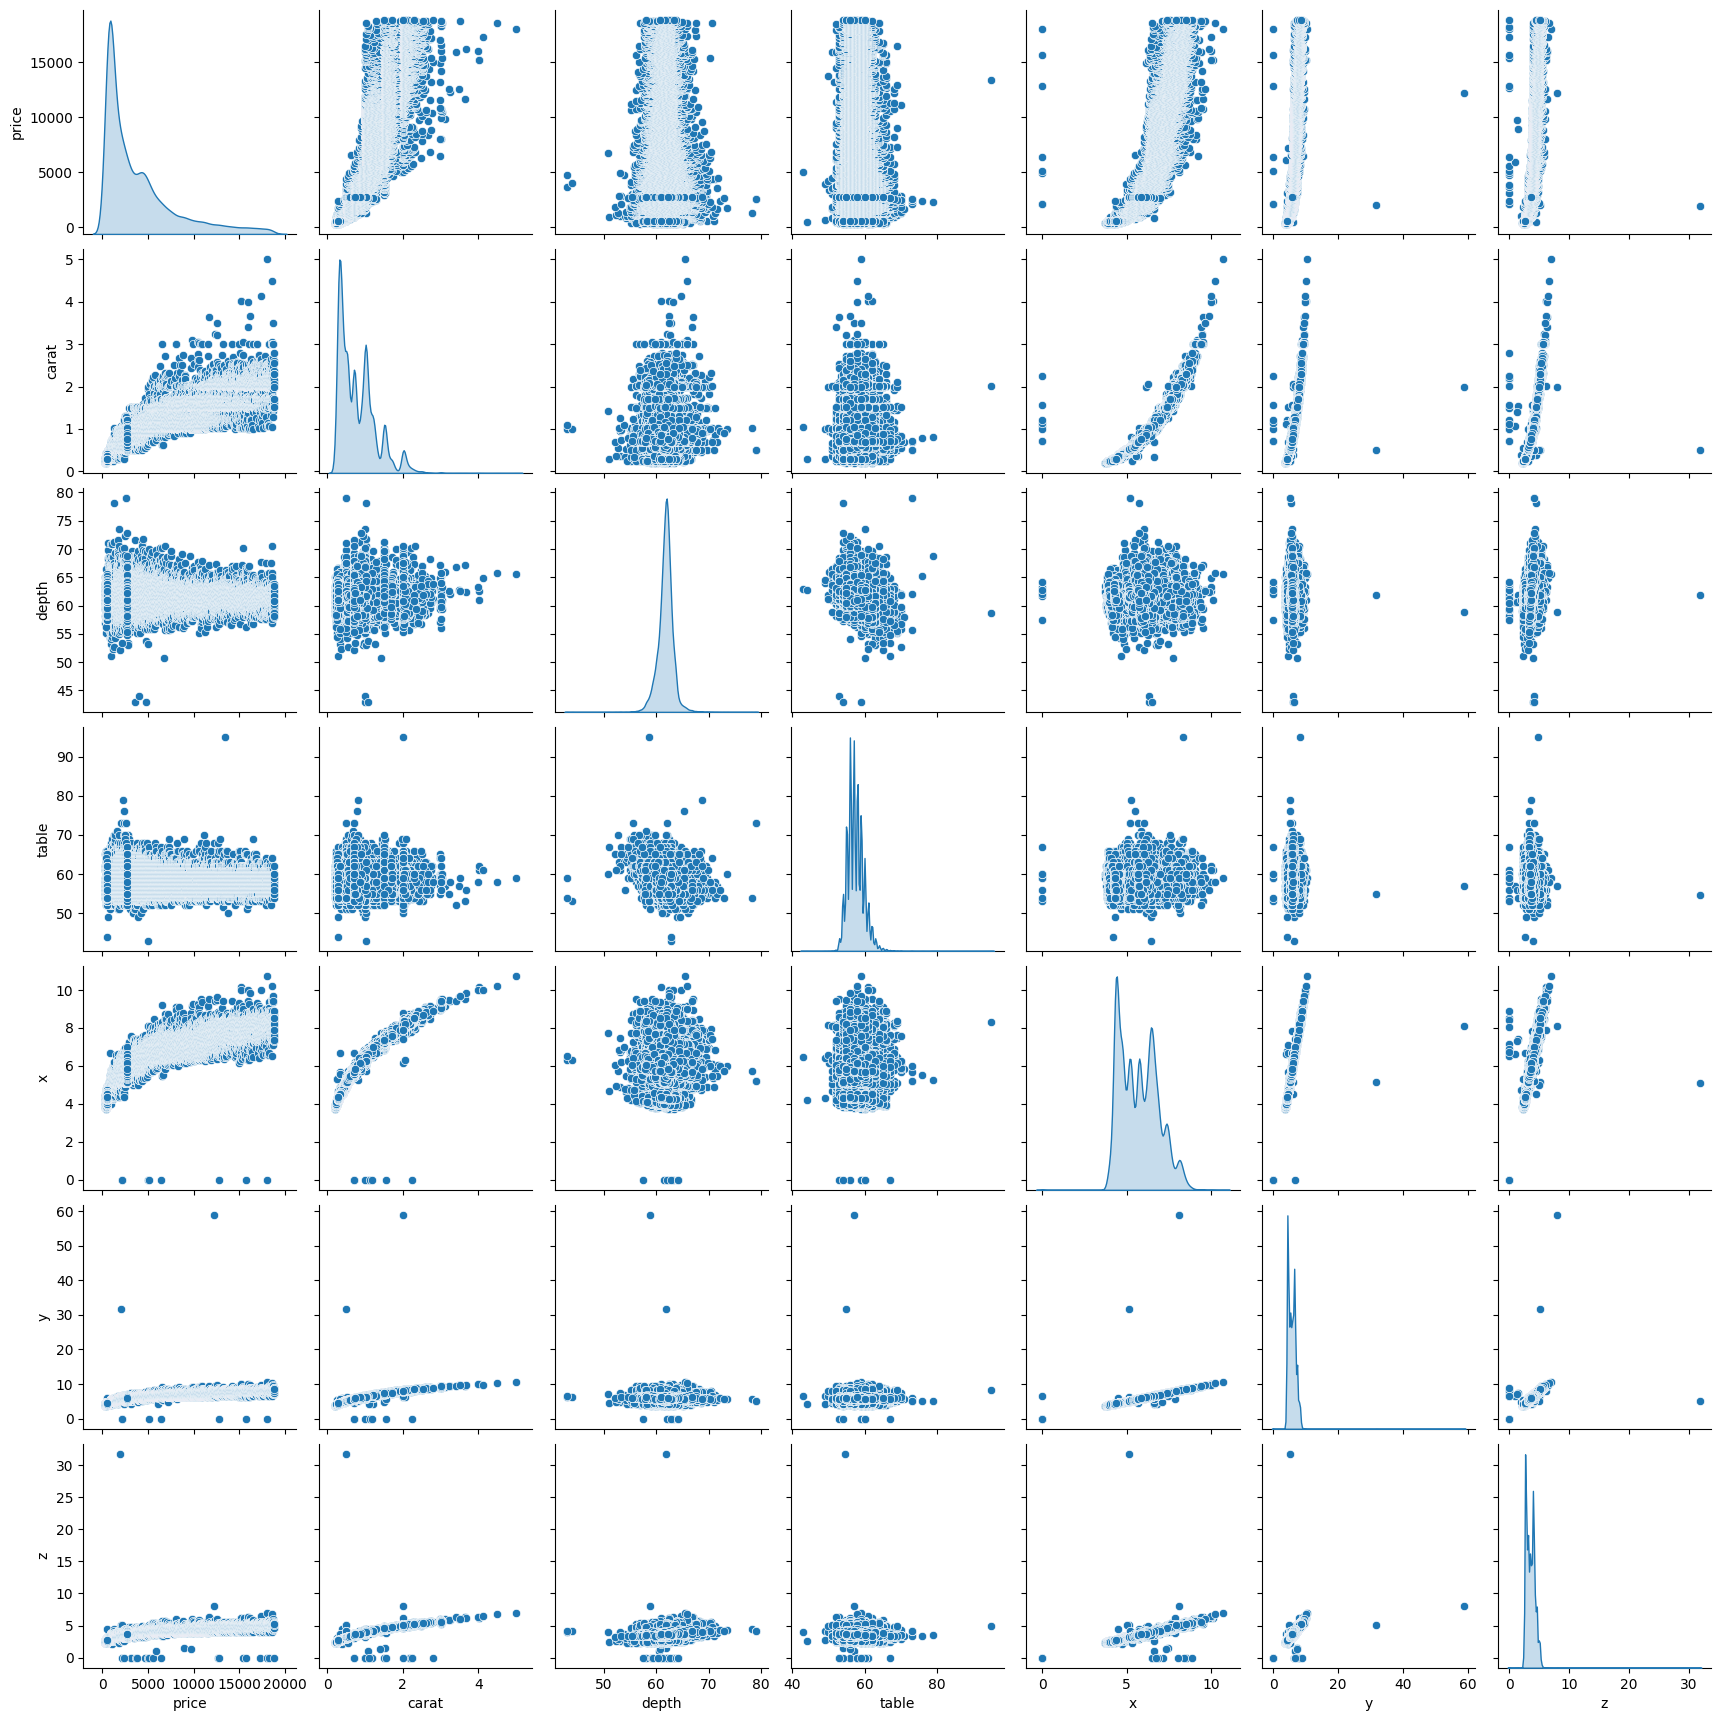

In [9]:
sns.pairplot(
    df[
        [
            "price",
            "carat",
            "depth",
            "table",
            "x",
            "y",
            "z"
        ]
    ],
    diag_kind="kde"
)

plt.show()

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

In [43]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
model = Pipeline([
    ("preprocessor", preprocessor),

    ("regressor", LinearRegression())
])

In [44]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [13]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 711.88577262 3191.72583727 1947.2464112  2077.29062598 9878.99820896
 3932.58482532 2372.62585284 2380.08706701 2844.11827559 6199.23891652]


In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 737.1513665933181
MSE : 1288705.4778516747
RMSE : 1135.2116445190627
R2 Score : 0.9189331350419387


In [15]:
result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred

})

result.head(20)

,Actual Price,Predicted Price
0,559,711.885773
1,2201,3191.725837
2,1238,1947.246411
3,1304,2077.290626
4,6901,9878.998209
5,3011,3932.584825
6,1765,2372.625853
7,1679,2380.087067
8,2102,2844.118276
9,4789,6199.238917


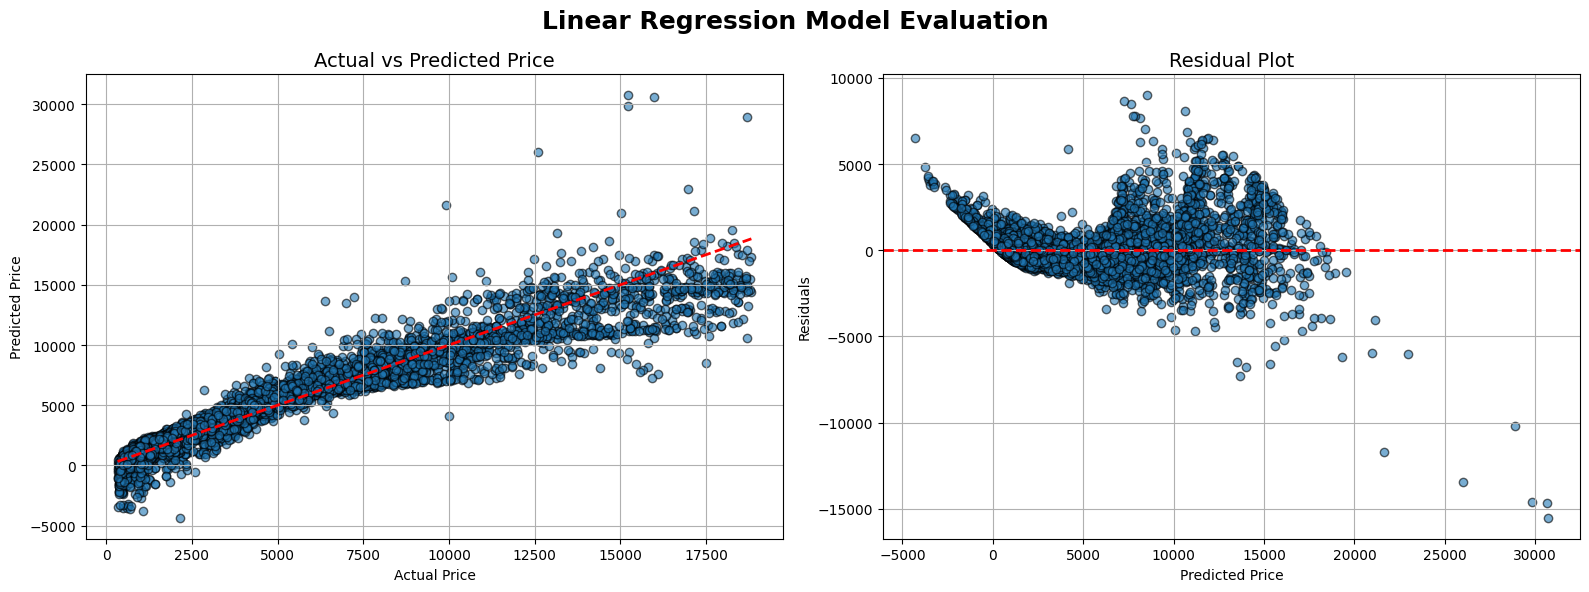

In [16]:
residuals = y_test - y_pred


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6,
    edgecolor="black"
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

axes[0].set_title("Actual vs Predicted Price", fontsize=14)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].grid(True)

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6,
    edgecolor="black"
)

axes[1].axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

axes[1].set_title("Residual Plot", fontsize=14)
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residuals")
axes[1].grid(True)

plt.suptitle("Linear Regression Model Evaluation", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.show()

In [33]:
import joblib
joblib.dump(model, "diamond_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
loaded_model = joblib.load("diamond_price_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [45]:
sample = pd.DataFrame({

    "carat":[0.7],

    "cut":["Ideal"],

    "color":["E"],

    "clarity":["VS2"],

    "depth":[61.5],

    "table":[55],

    "x":[5.7],

    "y":[5.6],

    "z":[3.5]

})

prediction = loaded_model.predict(sample)

print("Predicted Price : $", round(prediction[0],2))

Predicted Price : $ 3705.29


In [46]:
new_data = pd.DataFrame({

    "carat":[0.5,1.2,2.0],

    "cut":["Ideal","Premium","Very Good"],

    "color":["E","G","H"],

    "clarity":["VS1","SI1","VVS2"],

    "depth":[61.5,62.4,63.2],

    "table":[55,58,57],

    "x":[5.2,6.8,8.0],

    "y":[5.1,6.7,7.9],

    "z":[3.2,4.1,5.0]

})

pred = loaded_model.predict(new_data)

new_data["Predicted Price"] = pred

new_data

,carat,cut,color,clarity,depth,table,x,y,z,Predicted Price
0,0.5,Ideal,E,VS1,61.5,55,5.2,5.1,3.2,2282.149158
1,1.2,Premium,G,SI1,62.4,58,6.8,6.7,4.1,7130.225421
2,2.0,Very Good,H,VVS2,63.2,57,8.0,7.9,5.0,15629.995022


In [47]:
new_data.to_csv(
    "diamond_predictions.csv",
    index=False
)

print("Prediction File Saved")

Prediction File Saved
